In [1]:
from pathlib import Path
import json

import shap
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from IPython.display import display

c:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "models").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError(
            "Could not locate project root"
        )

    PROJECT_ROOT = PROJECT_ROOT.parent

MODELS = PROJECT_ROOT / "models"
REPORTS = PROJECT_ROOT / "reports" / "generated"
DATA = PROJECT_ROOT / "data" / "processed"

print("Project root:", PROJECT_ROOT)
print("Models:", MODELS)
print("Data:", DATA)
print("Reports:", REPORTS)

Project root: C:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM
Models: C:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM\models
Data: C:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM\data\processed
Reports: C:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM\reports\generated


In [3]:
model_path = MODELS / "obesity_risk_pipeline.joblib"
metadata_path = MODELS / "model_metadata.json"

final_model = joblib.load(model_path)

with open(metadata_path, "r") as file:
    metadata = json.load(file)

print("Model loaded successfully")
print("Metadata loaded successfully")

print("\nSelected Model:")
print(metadata["selected_candidate"])

print("\nSelection Metric:")
print(metadata["selection_metric"])

Model loaded successfully
Metadata loaded successfully

Selected Model:
Gradient Boosting - Tuned

Selection Metric:
Macro F1


In [4]:
X_test = pd.read_csv(
    DATA / "X_test.csv"
)

y_test = pd.read_csv(
    DATA / "y_test.csv"
).squeeze()

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (3114, 16)
y_test shape: (3114,)


In [5]:
# Generate predictions using the final trained pipeline
test_predictions = final_model.predict(X_test)

# Generate prediction probabilities if supported
if hasattr(final_model, "predict_proba"):
    test_probabilities = final_model.predict_proba(X_test)
else:
    test_probabilities = None

print("Predictions generated successfully")
print("Number of predictions:", len(test_predictions))

if test_probabilities is not None:
    print("Probability predictions available:", test_probabilities.shape)

Predictions generated successfully
Number of predictions: 3114
Probability predictions available: (3114, 7)


In [6]:
preprocessor = final_model.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()

print("Number of transformed features:", len(feature_names))

print("\nFirst 10 feature names:")
print(feature_names[:10])

Number of transformed features: 25

First 10 feature names:
['numerical__Age' 'numerical__Height' 'numerical__Weight'
 'numerical__FCVC' 'numerical__NCP' 'numerical__CH2O' 'numerical__FAF'
 'numerical__TUE' 'ordinal__CAEC' 'ordinal__CALC']


In [7]:
classifier = final_model.named_steps["classifier"]

feature_importance = classifier.feature_importances_

importance_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance": feature_importance
    }
)

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

display(
    importance_df.head(15)
)

,Feature,Importance
0,numerical__Weight,0.580780
1,numerical__FCVC,0.100567
2,numerical__Height,0.076616
3,nominal__Gender_Male,0.055070
4,nominal__Gender_Female,0.051784
5,numerical__Age,0.039661
6,numerical__TUE,0.025355
7,numerical__CH2O,0.015359
8,numerical__NCP,0.014888
9,ordinal__CALC,0.013725


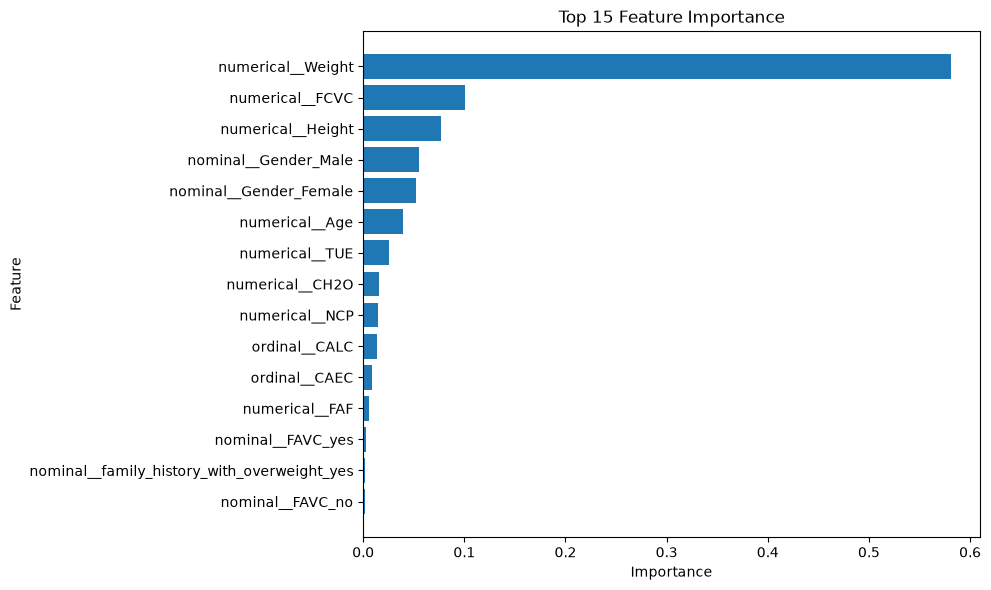

In [8]:
# Top 15 important features
top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importance")

plt.tight_layout()
plt.show()

In [9]:
# Extract pipeline components
preprocessor = final_model.named_steps["preprocessor"]
classifier = final_model.named_steps["classifier"]

# Transform test data
X_test_transformed = preprocessor.transform(X_test)

# Convert sparse matrix if required
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

print("Transformed feature shape:", X_test_transformed.shape)
print("Number of feature names:", len(feature_names))

# Background samples for SHAP
X_shap_background = X_test_transformed[:50]

# Prediction function for classifier only
def shap_predict_proba(data):
    return classifier.predict_proba(data)

# Create SHAP explainer
explainer = shap.PermutationExplainer(
    shap_predict_proba,
    X_shap_background,
    feature_names=list(feature_names),
    seed=42
)

# Generate SHAP values
X_shap_sample = X_test_transformed[:100]

shap_values = explainer(
    X_shap_sample
)

print("\nSHAP explanation generated successfully")
print("SHAP values shape:", shap_values.values.shape)

Transformed feature shape: (3114, 25)
Number of feature names: 25


PermutationExplainer explainer: 101it [00:11,  2.04it/s]                        


SHAP explanation generated successfully
SHAP values shape: (100, 25, 7)


C:\Users\User\AppData\Local\Temp\ipykernel_25248\322662727.py:29: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


Explaining class:
Obesity_Type_III

Class index:
4

Selected class SHAP shape:
(100, 25)

Feature count:
25


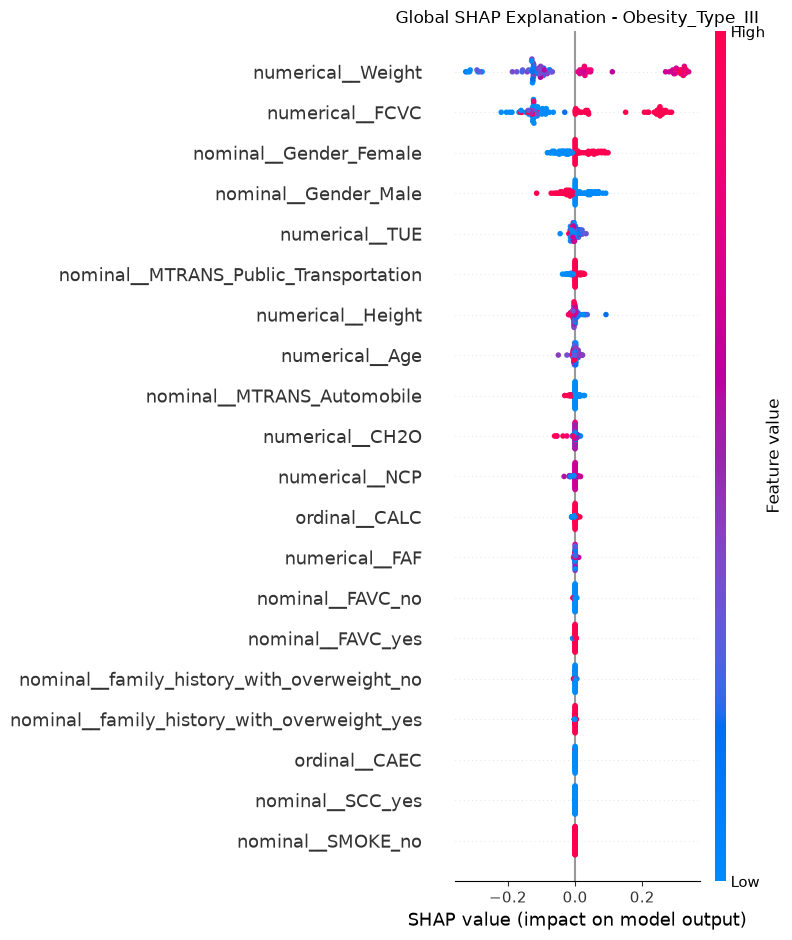

In [10]:
# Select class for explanation
explain_class = "Obesity_Type_III"

# Get class index from metadata
class_index = metadata["target_classes"].index(
    explain_class
)

print("Explaining class:")
print(explain_class)

print("\nClass index:")
print(class_index)

# Select SHAP values for selected class
selected_class_shap = (
    shap_values.values[:, :, class_index]
)

print("\nSelected class SHAP shape:")
print(selected_class_shap.shape)

print("\nFeature count:")
print(len(feature_names))

# Generate global SHAP summary plot
plt.figure(figsize=(12, 8))

shap.summary_plot(
    selected_class_shap,
    X_shap_sample,
    feature_names=feature_names,
    show=False
)

plt.title(
    f"Global SHAP Explanation - {explain_class}"
)

plt.tight_layout()

plt.show()

In [11]:
# Select one test sample
sample_index = 0

sample = X_shap_sample[sample_index]

# Generate prediction
prediction = classifier.predict(
    sample.reshape(1, -1)
)[0]

# Generate probabilities
probability = classifier.predict_proba(
    sample.reshape(1, -1)
)[0]

print("Sample index:", sample_index)

print("Predicted class:", prediction)

print("\nClass probabilities:")

# Use classifier classes to avoid mismatch
model_classes = [
    str(class_name)
    for class_name in classifier.classes_
]

for class_name, prob in zip(
    model_classes,
    probability
):
    print(
        f"{class_name}: {prob:.4f}"
    )

# Get SHAP values for selected sample
sample_shap = shap_values.values[sample_index]

# Find predicted class index
class_index = model_classes.index(
    str(prediction)
)

# Select SHAP values for predicted class
predicted_class_shap = (
    sample_shap[:, class_index]
)

print("\nSHAP values shape:")
print(predicted_class_shap.shape)

# Create explanation dataframe
local_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "SHAP Value": predicted_class_shap
    }
)

# Calculate contribution magnitude
local_df["Absolute Impact"] = (
    local_df["SHAP Value"]
    .abs()
)

# Sort by impact
local_df = local_df.sort_values(
    by="Absolute Impact",
    ascending=False
).reset_index(drop=True)

print("\nTop contributing features:")

display(
    local_df.head(10)
)

Sample index: 0
Predicted class: Obesity_Type_III

Class probabilities:
Insufficient_Weight: 0.0000
Normal_Weight: 0.0000
Obesity_Type_I: 0.0007
Obesity_Type_II: 0.0000
Obesity_Type_III: 0.9992
Overweight_Level_I: 0.0000
Overweight_Level_II: 0.0000

SHAP values shape:
(25,)

Top contributing features:


,Feature,SHAP Value,Absolute Impact
0,numerical__Weight,0.294051,0.294051
1,numerical__FCVC,0.252614,0.252614
2,nominal__Gender_Female,0.039750,0.039750
3,numerical__Height,0.031138,0.031138
4,nominal__Gender_Male,0.029245,0.029245
5,numerical__TUE,0.020831,0.020831
6,nominal__MTRANS_Public_Transportation,0.019963,0.019963
7,nominal__MTRANS_Automobile,0.014084,0.014084
8,numerical__CH2O,0.012749,0.012749
9,numerical__Age,0.010671,0.010671


In [12]:
# Create reports directory if not available
REPORTS.mkdir(
    parents=True,
    exist_ok=True
)

# Save feature importance results
importance_path = REPORTS / "feature_importance.csv"

importance_df.to_csv(
    importance_path,
    index=False
)

# Save local SHAP explanation
shap_local_path = REPORTS / "local_shap_explanation.csv"

local_df.to_csv(
    shap_local_path,
    index=False
)

print("Saved files:")
print(importance_path)
print(shap_local_path)

# Verify files exist
print("\nFile verification:")

print(
    "Feature importance exists:",
    importance_path.exists()
)

print(
    "Local SHAP explanation exists:",
    shap_local_path.exists()
)

Saved files:
C:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM\reports\generated\feature_importance.csv
C:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM\reports\generated\local_shap_explanation.csv

File verification:
Feature importance exists: True
Local SHAP explanation exists: True


In [13]:
feature_file = REPORTS / "feature_importance.csv"
shap_file = REPORTS / "local_shap_explanation.csv"

print("Feature importance file exists:",
      feature_file.exists())

print("Local SHAP explanation file exists:",
      shap_file.exists())

if feature_file.exists() and shap_file.exists():
    print("\nExplainability workflow completed successfully")
else:
    print("\nSome explainability outputs are missing")

Feature importance file exists: True
Local SHAP explanation file exists: True

Explainability workflow completed successfully
